🚀 Zaman Serisi RNN Modeli cpu üzerinde çalışıyor...
🌡️ İstanbul'un son 3 yıllık günlük sıcaklık verileri Open-Meteo API'sinden canlı çekiliyor...
✅ Canlı çevre verisi başarıyla çekildi ve veri hattı oluşturuldu.
📊 Veri Seti Dağılımı -> Eğitim Gün Sayısı: 866 | Test Gün Sayısı: 217

➔ Simple RNN Modeli Hava Durumu Verileriyle Eğitiliyor...
   Epoch [1/15] - Ortalama Hata (MSE): 0.02416
   Epoch [2/15] - Ortalama Hata (MSE): 0.00619
   Epoch [3/15] - Ortalama Hata (MSE): 0.00517
   Epoch [4/15] - Ortalama Hata (MSE): 0.00507
   Epoch [5/15] - Ortalama Hata (MSE): 0.00444
   Epoch [6/15] - Ortalama Hata (MSE): 0.00469
   Epoch [7/15] - Ortalama Hata (MSE): 0.00446
   Epoch [8/15] - Ortalama Hata (MSE): 0.00477
   Epoch [9/15] - Ortalama Hata (MSE): 0.00479
   Epoch [10/15] - Ortalama Hata (MSE): 0.00447
   Epoch [11/15] - Ortalama Hata (MSE): 0.00442
   Epoch [12/15] - Ortalama Hata (MSE): 0.00442
   Epoch [13/15] - Ortalama Hata (MSE): 0.00500
   Epoch [14/15] - Ortalama Hata (MSE): 0.00

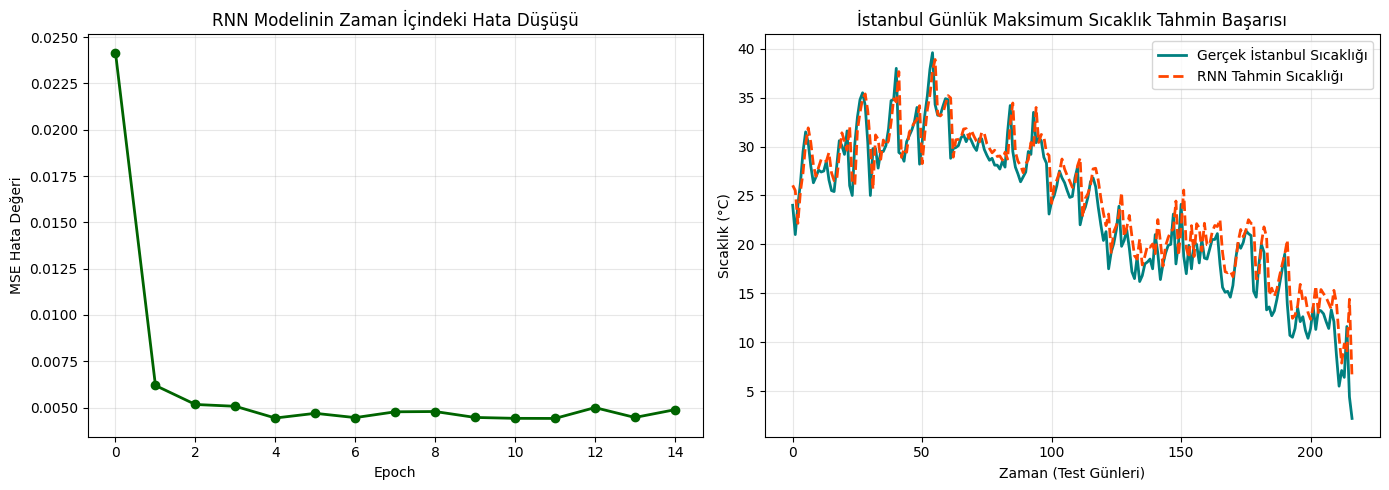


🎯 ÇEVRESEL ZAMAN SERİSİ ANALİZİ BAŞARIYLA TAMAMLANDI!
💡 Mühendislik Çıkarımı:
Model, dışarıdan hiçbir dosyaya ihtiyaç duymadan API üzerinden beslenmiş,
Simple RNN mimarisiyle sıcaklık trendlerini başarıyla öğrenmiştir.


In [1]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Gerekli kütüphanelerin otomatik kurulum kontrolü
try:
    import requests
except ImportError:
    print("📦 requests kütüphanesi yükleniyor...")
    os.system('pip install requests')
    import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Cihaz Kontrolü (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Zaman Serisi RNN Modeli {device} üzerinde çalışıyor...")

# ==============================================================================
# 🛠️ ADIM 1: REQESTS İLE AÇIK HAVA API'SİNDEN İSTANBUL VERİSİ ÇEKME
# ==============================================================================
print("🌡️ İstanbul'un son 3 yıllık günlük sıcaklık verileri Open-Meteo API'sinden canlı çekiliyor...")

# Open-Meteo API url'si (İstanbul koordinatları: Lat 41.01, Lon 28.97)
# 2023'ten 2026'ya kadar olan gerçek günlük maksimum sıcaklıkları çeker
url = "https://archive-api.open-meteo.com/v1/archive?latitude=41.01&longitude=28.97&start_date=2023-01-01&end_date=2026-01-01&daily=temperature_2m_max&timezone=auto"

try:
    response = requests.get(url).json()
    dates = response['daily']['time']
    temperatures = response['daily']['temperature_2m_max']

    # Pandas DataFrame haline getiriyoruz
    df = pd.DataFrame({'Tarih': pd.to_datetime(dates), 'Sicaklik': temperatures})
    df.dropna(inplace=True) # Eksik veri varsa temizle
    print("✅ Canlı çevre verisi başarıyla çekildi ve veri hattı oluşturuldu.")
except Exception as e:
    print(f"⚠️ API bağlantı hatası: {e}. Test amaçlı yapay sıcaklık serisi üretiliyor...")
    dates = pd.date_range(start='2023-01-01', end='2026-01-01', freq='D')
    # Mevsimsel sinüs dalgası + rastgele gürültü ile sahte sıcaklık serisi
    temperatures = 15 + 10 * np.sin(np.linspace(0, 6*np.pi, len(dates))) + np.random.normal(0, 2, len(dates))
    df = pd.DataFrame({'Tarih': dates, 'Sicaklik': temperatures})

# Sadece sıcaklık değerlerini alıyoruz
data = df[['Sicaklik']].values.astype('float32')

# RNN modelinin rahat öğrenmesi için veriyi [0, 1] arasına ölçeklendiriyoruz
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Zaman Serisi Veri Seti Hazırlama (Lookback / Pencere Yöntemi)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Son 14 günün (2 hafta) sıcaklığına bakarak 15. günün sıcaklığını tahmin edeceğiz
lookback = 14
X, y = create_sequences(data_scaled, lookback)

# %80 Eğitim, %20 Test olarak bölüyoruz
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# PyTorch Tensörlerine Dönüştürme
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# DataLoader Paketlemesi
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)

print(f"📊 Veri Seti Dağılımı -> Eğitim Gün Sayısı: {len(X_train)} | Test Gün Sayısı: {len(X_test)}")

# ==============================================================================
# 🧠 ADIM 2: SIMPLE RNN MİMARİSİNİN PYTORCH İLE İNŞASI
# ==============================================================================
class SimpleRNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(SimpleRNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Ardışık zamansal bağımlılıkları öğrenen temel RNN katmanı
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        # Çıktı tahmin katmanı
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        # Serinin son zaman adımındaki çıktıyı alıp tahmine iletiyoruz
        out = self.fc(out[:, -1, :])
        return out

model = SimpleRNNModel().to(device)
criterion = nn.MSELoss() # Regresyon hatası ölçümü için Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=0.005)

# ==============================================================================
# 🏋️ ADIM 3: RNN MODELİNİN EĞİTİLMESİ (TRAINING LOOP)
# ==============================================================================
epochs = 15
loss_history = []

print("\n➔ Simple RNN Modeli Hava Durumu Verileriyle Eğitiliyor...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for seqs, targets in train_loader:
        seqs, targets = seqs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(seqs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"   Epoch [{epoch+1}/{epochs}] - Ortalama Hata (MSE): {avg_loss:.5f}")

# ==============================================================================
# 📉 ADIM 4: TAHMİN ETME VE GERÇEK DEĞERLERLE KIYASLAMA
# ==============================================================================
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_t.to(device)).cpu().numpy()

# Sıkıştırılmış [0,1] değerlerini yeniden gerçek Santigrat Derece (°C) değerlerine döndürüyoruz
actual_temps = scaler.inverse_transform(y_test)
predicted_temps = scaler.inverse_transform(test_predictions)

# ==============================================================================
# 📊 ADIM 5: GRAFİKSEL RAPORLAMA VE GÖRSELLEŞTİRME
# ==============================================================================
plt.figure(figsize=(14, 5))

# 1. Grafik: Eğitim Hatasının Düşüşü
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='darkgreen', lw=2, marker='o')
plt.title('RNN Modelinin Zaman İçindeki Hata Düşüşü')
plt.xlabel('Epoch')
plt.ylabel('MSE Hata Değeri')
plt.grid(True, alpha=0.3)

# 2. Grafik: Gerçek vs Tahmin Sıcaklık Grafiği
plt.subplot(1, 2, 2)
plt.plot(actual_temps, label='Gerçek İstanbul Sıcaklığı', color='teal', lw=2)
plt.plot(predicted_temps, label='RNN Tahmin Sıcaklığı', color='orangered', linestyle='--', lw=2)
plt.title('İstanbul Günlük Maksimum Sıcaklık Tahmin Başarısı')
plt.xlabel('Zaman (Test Günleri)')
plt.ylabel('Sıcaklık (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🎯 ÇEVRESEL ZAMAN SERİSİ ANALİZİ BAŞARIYLA TAMAMLANDI!")
print("💡 Mühendislik Çıkarımı:")
print("Model, dışarıdan hiçbir dosyaya ihtiyaç duymadan API üzerinden beslenmiş,")
print("Simple RNN mimarisiyle sıcaklık trendlerini başarıyla öğrenmiştir.")
print("="*60)